# Exercise 1: Forward Intersection and Spatial Resection with DLT

This lab notebook combines two fundamental techniques in photogrammetry and computer vision:

### Part 1: Forward Intersection (Vorwärtsschnitt)
Forward intersection is a technique that determines the position of unknown points by observing them from two or more known positions. In photogrammetric applications, this involves identifying corresponding points in multiple oriented images and calculating where their projection rays intersect in three-dimensional space, resulting in the 3D coordinates of the target point.

**Topics covered:**
- Point selection and correspondence matching
- Vector-based intersection analysis
- Matrix-based evaluation using SVD
- Error calculation and analysis

### Part 2: Spatial Resection and Direct Linear Transformation (DLT)
Spatial resection involves determining camera parameters from known 3D-2D correspondences. The Direct Linear Transformation (DLT) algorithm computes the projection matrix directly from point correspondences.

**Topics covered:**
- 3D point projection to pixel coordinates
- Direct Linear Transformation (DLT) implementation
- Camera parameter reconstruction from DLT matrix
- Accuracy analysis and comparison

### Setup and Imports


In [2]:
!pip install opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 129.1 MB/s eta 0:00:00a 0:00:01


In [1]:
# Import the necessary Libraries 
!pip install scipy
import numpy as np 
import matplotlib.pyplot as plt
import cv2 as cv
import os
from scipy.linalg import svd, lstsq
from scipy.optimize import least_squares

## Part 1: Forward Intersection (Vorwärtsschnitt)

### Setup: Camera Parameters and Data Loading

Within the following part the parameters of the internal and external orientation are provided and read to the storage. The code block needs to be executed every time the kernel is restarted. 

**Hint:** It is highly recommended to check the source files mentioned in the comments below to match the parameters in the code with the parameters from the file. There is a high chance to receive questions related to that within the exam.


In [4]:
# Paths for the image pair
image1_path = 'R0020851.jpg'
image2_path = 'R0020852.jpg'

# Paths for saving/loading points
points_image1_file = 'points_image1.npy'
points_image2_file = 'points_image2.npy'

## Information is provided in the files "Aerial6ori.sec" and "Aerial7ori.sec"
K = np.array([[-3933.36363636, -0.00000000, 2143.50000000], [-0.00000000, 3933.36363636, 1423.50000000], [0.00000000, 0.00000000, 1.00000000]])
c = 21.6335e-3
pixSize = 5.5e-6

R6 = np.array([[-0.827570749773, -0.557530411593, 0.065471324026], [0.549857636160, -0.828569770064, -0.105492730048], [0.113062965097, -0.051302790236, 0.992262460056]])
xTrans6 = np.array([512980.995110, 5427701.526710, 514.794290])

R7 = np.array([[-0.866544118547, -0.490057510421, -0.094577624687], [0.490759244246, -0.871123481449, 0.017298677877], [-0.090866136699, -0.031424776041, 0.995367182829]])
xTrans7 = np.array([512966.499230, 5427725.063170, 517.490680])

## Information is provided in the file "Signalized Points"
# Control points in 3D space (5 points in this case)
ctlPts = np.array([[512868.940, 512982.899, 513047.601, 512781.152, 512866.691],
                   [5427723.833, 5427801.281, 5427704.443, 5427721.195, 5427556.801],
                   [280.885, 323.376, 326.998, 229.286, 229.433]])

### Task 1: Point Selection (2 Points) 

The provided tool below allows to measure and store identical points of two corresponding images. Use the graphical interface to measure identical points in the image pair implemented (minimum of four point pairs). 

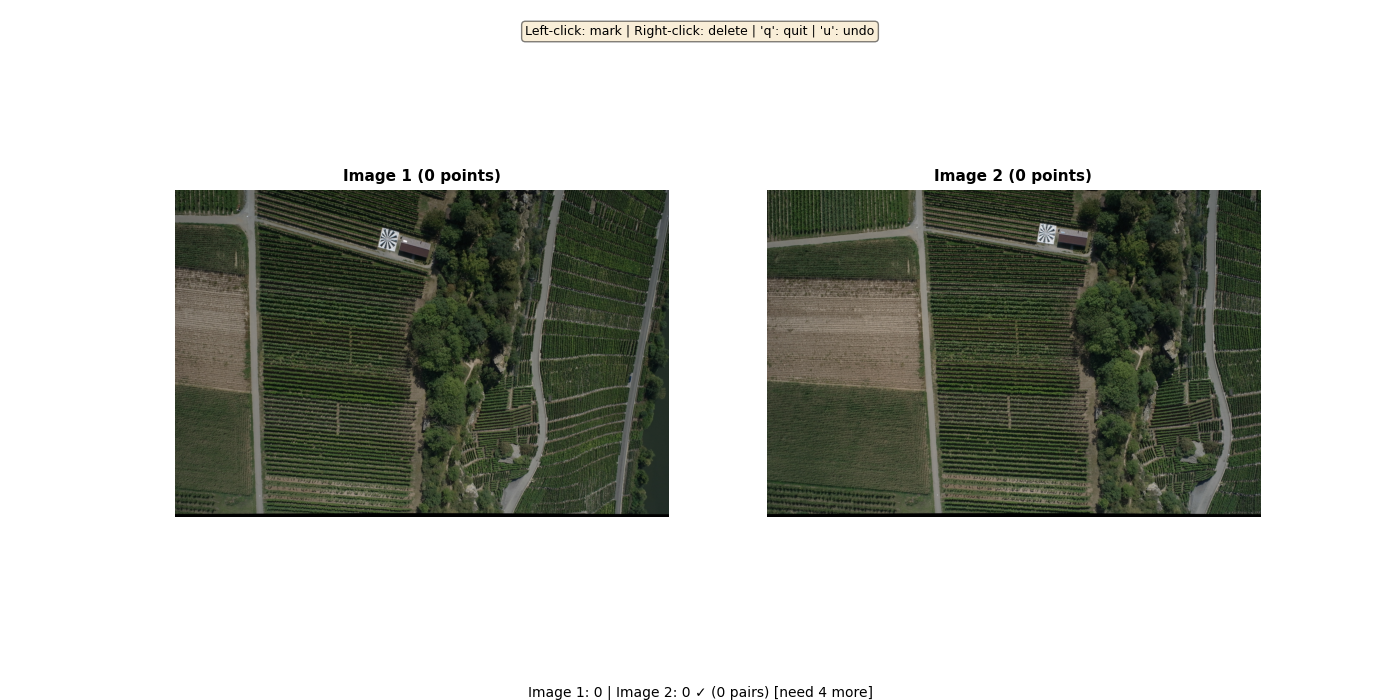

In [5]:
%matplotlib widget

class PointMarker:
    def __init__(self, img1_path, img2_path, save_file1='points_image1.npy', save_file2='points_image2.npy'):
        self.save_file1, self.save_file2 = save_file1, save_file2
        self.points1, self.points2 = self._load_points()
        
        # Load images
        img1 = cv.imread(img1_path)
        img2 = cv.imread(img2_path)
        self.img1 = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
        self.img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)
        
        # Setup plot
        self.fig, (self.ax1, self.ax2) = plt.subplots(1, 2, figsize=(14, 7))
        self._setup_plot()
        self.fig.canvas.mpl_connect('button_press_event', self._onclick)
        self.fig.canvas.mpl_connect('key_press_event', self._onkey)
        self.fig.canvas.mpl_connect('close_event', self._onclose)
        
    def _load_points(self):
        """Load saved points or initialize empty lists."""
        try:
            p1 = np.load(self.save_file1, allow_pickle=True).tolist()
            p2 = np.load(self.save_file2, allow_pickle=True).tolist()
            min_len = min(len(p1), len(p2))
            if min_len > 0:
                print(f"Loaded {min_len} point pairs.")
            return p1[:min_len], p2[:min_len]
        except FileNotFoundError:
            return [], []
    
    def _save_points(self):
        """Save points to files."""
        np.save(self.save_file1, self.points1)
        np.save(self.save_file2, self.points2)
    
    def _plot_points(self, redraw=True):
        """Update plot with current points."""
        for ax, img, points, color, title in [
            (self.ax1, self.img1, self.points1, 'red', 'Image 1'),
            (self.ax2, self.img2, self.points2, 'blue', 'Image 2')
        ]:
            if redraw:
                ax.clear()
                ax.imshow(img)
                ax.axis('off')
                ax.set_aspect('equal')

            ax.set_title(f'{title} ({len(points)} points)', fontsize=11, fontweight='bold')            
            for idx, (x, y) in enumerate(points):
                ax.plot(x, y, f'{color[0]}o', markersize=8, markeredgecolor=color, markeredgewidth=2)
                ax.text(x+8, y-8, f'{idx+1}', color=color, fontsize=10, fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.7))
        
        # Status
        n1, n2 = len(self.points1), len(self.points2)
        status = f"Image 1: {n1} | Image 2: {n2}"
        if n1 == n2:
            status += f" ✓ ({n1} pairs)" + (" [OK]" if n1 >= 4 else f" [need {4-n1} more]")
        else:
            status += " ⚠ Unpaired!"
        self.fig.suptitle(status, fontsize=10, y=0.02)
        self.fig.canvas.draw()
    
    def _setup_plot(self):
        """Initial plot setup."""
        self._plot_points()
        instructions = "Left-click: mark | Right-click: delete | 'q': quit | 'u': undo"
        self.fig.text(0.5, 0.95, instructions, ha='center', fontsize=9,
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    def _find_closest_point(self, x, y, points, threshold=20):
        """Find closest point within threshold."""
        if not points:
            return -1
        dists = np.sqrt((np.array(points)[:, 0] - x)**2 + (np.array(points)[:, 1] - y)**2)
        idx = np.argmin(dists)
        return idx if dists[idx] < threshold else -1
    
    def _onclick(self, event):
        """Handle mouse clicks."""
        if plt.get_current_fig_manager().toolbar.mode != '' or event.xdata is None:
            return
        
        x, y = int(event.xdata), int(event.ydata)
        is_img1 = event.inaxes == self.ax1
        points = self.points1 if is_img1 else self.points2
        
        if event.button == 3:  # Right click: delete
            idx = self._find_closest_point(x, y, points)
            if idx >= 0 and idx < len(self.points1) and idx < len(self.points2):
                self.points1.pop(idx)
                self.points2.pop(idx)
                self._plot_points()
                self._save_points()
        else:  # Left click: add
            if is_img1:
                self.points1.append((x, y))
            else:
                if len(self.points2) >= len(self.points1):
                    return
                self.points2.append((x, y))
            self._plot_points(redraw=False)
            self._save_points()
    
    def _onkey(self, event):
        """Handle keyboard shortcuts."""
        if event.key == 'q':
            self._save_points()
            n1, n2 = len(self.points1), len(self.points2)
            plt.close()
        elif event.key == 'u':
            if len(self.points1) == len(self.points2) and len(self.points1) > 0:
                self.points1.pop()
                self.points2.pop()
                self._plot_points()
                self._save_points()
    
    def _onclose(self, event):
        """Handle figure close."""
        self._save_points()

# Create and show the interactive tool
marker = PointMarker(image1_path, image2_path, points_image1_file, points_image2_file)
plt.show()

# Make points accessible for subsequent cells
points_image1 = marker.points1
points_image2 = marker.points2

In [ ]:
print("Marked Points on Image 1:", points_image1)
print("Marked Points on Image 2:", points_image2)

In [ ]:
## Do not change cell - required for auto-grading ## 

### Task 2: Intersection - Vector based analysis (5 Points)

Complete the implementation of the method `calculate_oc_vector()` without using predefined methods of OpenCV or similar libraries. 

**Hint:** To calculate the inverse of a matrix (`np.linalg.inv()`) or to solve a linear equation system (`np.linalg.solve()`) the corresponding NumPy functions can be used.

**Result:** Check the output format described in the Method-Description in the code block below!


In [9]:
def visualize_intersection_results(result, xTrans6, xTrans7, method_name="Forward Intersection"):
    # Extract data
    point_indices = result[0, :].astype(int)
    X_coords = result[1, :]
    Y_coords = result[2, :]
    Z_coords = result[3, :]
    errors = result[4, :]
    
    # Print formatted table
    print("="*80)
    print(f"FORWARD INTERSECTION RESULTS ({method_name})")
    print("="*80)
    print(f"{'Point':<8} {'X (m)':<15} {'Y (m)':<15} {'Z (m)':<15} {'Error':<15}")
    print("-"*80)
    for i in range(len(point_indices)):
        print(f"{point_indices[i]:<8} {X_coords[i]:<15.3f} {Y_coords[i]:<15.3f} {Z_coords[i]:<15.3f} {errors[i]:<15.6f}")
    print("-"*80)
    if np.any(errors != 0):
        print(f"Mean Error: {np.mean(np.abs(errors)):.6f}")
        print(f"Max Error:  {np.max(np.abs(errors)):.6f}")
    else:
        print("Note: Error values are set to 0 (not calculated in this method)")

In [10]:
def calculate_oc_vector(points_image1, points_image2, K, R6, R7, xTrans6, xTrans7):
    """
    Calculate object coordinates and expected error from corresponding image points.
    
    Parameters:
    -----------
    points_image1 : list or numpy.ndarray
        List of points from first image as (x,y) coordinates
    points_image2 : list or numpy.ndarray
        List of points from second image as (x,y) coordinates
    K : numpy.ndarray
        Camera intrinsic matrix (3x3)
    R6 : numpy.ndarray
        Rotation matrix for first camera (3x3)
    R7 : numpy.ndarray
        Rotation matrix for second camera (3x3)
    xTrans6 : numpy.ndarray
        Translation vector for first camera (3,)
    xTrans7 : numpy.ndarray
        Translation vector for second camera (3,)
    
    Returns:
    --------
    numpy.ndarray
        Array containing:
        - Row 1: Point indices (1-based)
        - Rows 2-4: 3D coordinates (X, Y, Z)
        - Row 5: Expected error
    """
    result = None
    
    # YOUR CODE HERE
    # Convert input point lists to NumPy arrays
    p1 = np.array(points_image1)
    p2 = np.array(points_image2)
    n_points = p1.shape[0]
    
    # Inverse of intrinsic matrix
    K_inv = np.linalg.inv(K)
    
    # Prepare result array: 5 x N
    result = np.zeros((5, n_points))
    
    for i in range(n_points):
    
        # Homogeneous image coordinates
        x1 = np.array([p1[i, 0], p1[i, 1], 1.0])
        x2 = np.array([p2[i, 0], p2[i, 1], 1.0])
    
        # Viewing direction in camera coordinate system
        v1 = K_inv @ x1
        v2 = K_inv @ x2
    
        # Transform directions to object (world) coordinate system
        d1 = R6.T @ v1
        d2 = R7.T @ v2
    
        # Normalize direction vectors
        d1 = d1 / np.linalg.norm(d1)
        d2 = d2 / np.linalg.norm(d2)
    
        # Solve for closest approach between two rays
        A = np.column_stack((d1, -d2))
        b = xTrans7 - xTrans6
        lambdas, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        l1, l2 = lambdas
    
        # Compute closest points on each ray
        P1 = xTrans6 + l1 * d1
        P2 = xTrans7 + l2 * d2
    
        # Final object point and intersection error
        P = 0.5 * (P1 + P2)
        error = np.linalg.norm(P1 - P2)
    
        # Store results
        result[0, i] = i + 1
        result[1, i] = P[0]
        result[2, i] = P[1]
        result[3, i] = P[2]
        result[4, i] = error
    
        
    return result

# Calculate results and visualize
result_vector = calculate_oc_vector(points_image1, points_image2, K, R6, R7, xTrans6, xTrans7)
visualize_intersection_results(result_vector, xTrans6, xTrans7, method_name="Vector-based method")

FORWARD INTERSECTION RESULTS (Vector-based method)
Point    X (m)           Y (m)           Z (m)           Error          
--------------------------------------------------------------------------------
1        513048.052      5427705.090     327.044         0.557437       
2        512984.270      5427801.968     320.188         0.214820       
3        512872.077      5427749.560     284.920         1.684786       
4        512935.935      5427616.333     277.575         0.659949       
5        512952.422      5427725.261     330.279         1.391762       
--------------------------------------------------------------------------------
Mean Error: 0.901751
Max Error:  1.684786


In [ ]:
## Do not change cell - required for auto-grading ## 

**Question:** What is the unit of the error calculated within the task above?


The error is expressed in meters, as it represents the Euclidean distance between the closest points of two viewing rays in object space.

**Question:** What happens if you measure corresponding points in more than two images? Would the vector-based approach still work? Why or why not? What would be the appropriate method to use in this case?

The vector-based forward intersection method is limited to two images only.
When more than two images are used, the rays do not intersect at a single point due to measurement noise. In this case, the vector-based approach is no longer sufficient.
The appropriate method is a least-squares adjustment, such as multi-ray forward intersection or bundle adjustment, which minimizes the reprojection error using all available observations.

### Task 3 - Matrix based evaluation (5 Points)

Complete the implementation of the method `calculate_oc_matrix()` without using predefined methods of OpenCV or similar libraries. Within this task the Projection Matrix shall be used to set up the required system of linear equations. It is required to use **SVD** to get an appropriate solution.

**Hint:** Within this part of the task the error is set to `0`. 

**Result:** Check the output format described in the Method-Description in the code block below!


In [12]:
def calculate_oc_matrix(points_image1, points_image2, K, R6, R7, xTrans6, xTrans7):
    """
    Calculate object coordinates using SVD method from corresponding image points.
    
    Parameters:
    -----------
    points_image1 : list or numpy.ndarray
        List of points from first image as (x,y) coordinates
    points_image2 : list or numpy.ndarray
        List of points from second image as (x,y) coordinates
    K : numpy.ndarray
        Camera intrinsic matrix (3x3)
    R6 : numpy.ndarray
        Rotation matrix for first camera (3x3)
    R7 : numpy.ndarray
        Rotation matrix for second camera (3x3)
    xTrans6 : numpy.ndarray
        Translation vector for first camera (3,)
    xTrans7 : numpy.ndarray
        Translation vector for second camera (3,)
    
    Returns:
    --------
    numpy.ndarray
        Array containing:
        - Row 1: Point indices (1-based)
        - Rows 2-4: 3D coordinates (X, Y, Z)
        - Row 5: 0
    """
    result = None
    
    # YOUR CODE HERE
    # Convert input point lists to NumPy arrays
    p1 = np.array(points_image1)
    p2 = np.array(points_image2)
    n_points = p1.shape[0]
    
    # Build projection matrices for both cameras
    P6 = K @ np.hstack((R6, -R6 @ xTrans6.reshape(3, 1)))
    P7 = K @ np.hstack((R7, -R7 @ xTrans7.reshape(3, 1)))
    
    # Prepare result array: 5 x N
    result = np.zeros((5, n_points))
    
    for i in range(n_points):
    
        x1, y1 = p1[i]
        x2, y2 = p2[i]
    
        # Build linear system A·X = 0
        A = np.zeros((4, 4))
        A[0] = x1 * P6[2] - P6[0]
        A[1] = y1 * P6[2] - P6[1]
        A[2] = x2 * P7[2] - P7[0]
        A[3] = y2 * P7[2] - P7[1]
    
        # Solve using SVD
        _, _, Vt = np.linalg.svd(A)
        X_h = Vt[-1]
        X_h = X_h / X_h[3]  # dehomogenize
    
        # Store results
        result[0, i] = i + 1
        result[1, i] = X_h[0]
        result[2, i] = X_h[1]
        result[3, i] = X_h[2]
        result[4, i] = 0.0
    
        
    return result

# Calculate results and visualize
result_P = calculate_oc_matrix(points_image1, points_image2, K, R6, R7, xTrans6, xTrans7)
visualize_intersection_results(result_P, xTrans6, xTrans7, method_name="Matrix-based method")

FORWARD INTERSECTION RESULTS (Matrix-based method)
Point    X (m)           Y (m)           Z (m)           Error          
--------------------------------------------------------------------------------
1        513047.901      5427705.103     327.386         0.000000       
2        512984.266      5427801.916     320.316         0.000000       
3        512871.465      5427749.757     283.647         0.000000       
4        512935.855      5427616.109     276.978         0.000000       
5        512952.410      5427725.262     330.258         0.000000       
--------------------------------------------------------------------------------
Note: Error values are set to 0 (not calculated in this method)


In [ ]:
## Do not change cell - required for auto-grading ## 

**Question:** According to the task above we have not calculated an error yet. What would be an appropriate way to estimate an error using the matrix based analysis?


An appropriate way to estimate the error in the matrix-based approach is to compute the reprojection error.
After estimating the 3D object point using the SVD-based solution, the point can be reprojected into each image using the corresponding projection matrix.
The difference between the measured image points and the reprojected image points represents the reprojection error.
This error can be quantified using the Euclidean norm or evaluated within a least-squares framework to obtain residuals and uncertainty estimates.

### Task 4: Error Calculation Implementation (5 Points)

Implement the error calculation procedure you proposed in the previous task.

**Result:** Please check the method description and expected output format in the code block below!


In [13]:
def calculate_error(object_coords, points_image1, points_image2, K, R6, R7, xTrans6, xTrans7):
    """
    Calculate reprojection error for 3D points projected back onto both images.
    
    Parameters:
    -----------
    object_coords : numpy.ndarray
        Array containing 3D coordinates (output from calculate_oc_matrix)
    points_image1 : list or numpy.ndarray
        Original points from first image as (x,y) coordinates
    points_image2 : list or numpy.ndarray
        Original points from second image as (x,y) coordinates
    K : numpy.ndarray
        Camera intrinsic matrix (3x3)
    R6 : numpy.ndarray
        Rotation matrix for first camera (3x3)
    R7 : numpy.ndarray
        Rotation matrix for second camera (3x3)
    xTrans6 : numpy.ndarray
        Translation vector for first camera (3,)
    xTrans7 : numpy.ndarray
        Translation vector for second camera (3,)
        
    Returns:
    --------
    tuple
        - Mean reprojection error across all points
        - Array of individual point errors
        - Reprojected points for camera 1
        - Reprojected points for camera 2
    """
    mean_error = None
    point_errors = None
    proj_points1 = None
    proj_points2 = None
    
    # YOUR CODE HERE
    # Extract 3D object coordinates (rows 1–3 of object_coords)
    X_obj = object_coords[1:4, :].T
    n_points = X_obj.shape[0]
    
    # Convert image points to NumPy arrays
    p1 = np.array(points_image1)
    p2 = np.array(points_image2)
    
    # Build projection matrices
    P6 = K @ np.hstack((R6, -R6 @ xTrans6.reshape(3, 1)))
    P7 = K @ np.hstack((R7, -R7 @ xTrans7.reshape(3, 1)))
    
    # Initialize outputs
    proj_points1 = np.zeros((n_points, 2))
    proj_points2 = np.zeros((n_points, 2))
    point_errors = np.zeros(n_points)
    
    for i in range(n_points):
    
        # Homogeneous 3D point
        X_h = np.hstack((X_obj[i], 1.0))
    
        # Reproject into image 1
        x1_proj = P6 @ X_h
        x1_proj = x1_proj / x1_proj[2]
        proj_points1[i] = x1_proj[:2]
    
        # Reproject into image 2
        x2_proj = P7 @ X_h
        x2_proj = x2_proj / x2_proj[2]
        proj_points2[i] = x2_proj[:2]
    
        # Reprojection error (Euclidean distance in image space)
        e1 = np.linalg.norm(p1[i] - proj_points1[i])
        e2 = np.linalg.norm(p2[i] - proj_points2[i])
        point_errors[i] = 0.5 * (e1 + e2)
    
    # Mean reprojection error
    mean_error = np.mean(point_errors)

    
    return mean_error, point_errors, proj_points1, proj_points2

mean_error, result_P[-1, :], proj_points1, proj_points2 = calculate_error(result_P, points_image1, points_image2, K, R6, R7, xTrans6, xTrans7)
visualize_intersection_results(result_vector, xTrans6, xTrans7, method_name="Vector-based method")
print("\nvs.\n")
visualize_intersection_results(result_P, xTrans6, xTrans7, method_name="Matrix-based method")

FORWARD INTERSECTION RESULTS (Vector-based method)
Point    X (m)           Y (m)           Z (m)           Error          
--------------------------------------------------------------------------------
1        513048.052      5427705.090     327.044         0.557437       
2        512984.270      5427801.968     320.188         0.214820       
3        512872.077      5427749.560     284.920         1.684786       
4        512935.935      5427616.333     277.575         0.659949       
5        512952.422      5427725.261     330.279         1.391762       
--------------------------------------------------------------------------------
Mean Error: 0.901751
Max Error:  1.684786

vs.

FORWARD INTERSECTION RESULTS (Matrix-based method)
Point    X (m)           Y (m)           Z (m)           Error          
--------------------------------------------------------------------------------
1        513047.901      5427705.103     327.386         6.133643       
2        512984.266    

In [ ]:
## Do not change cell - required for auto-grading ## 

**Question:** What is the unit of the error you have calculated? If you compare the two methods for determining the error - which error is more meaningful in our current case and why?

The reprojection error calculated in this task is expressed in pixels, since it represents the distance between the observed image points and the reprojected image points in image space.

When comparing the two error estimation methods, the reprojection error is more meaningful in the current case. This is because it directly reflects how well the estimated 3D points explain the original image measurements and is defined in the observation space of the camera.

The vector-based error represents a geometric distance between two viewing rays in object space and does not directly indicate how accurately the image observations are reproduced. Therefore, for evaluating the quality of the reconstruction with respect to the image measurements, the reprojection error is the more appropriate and interpretable metric.

## Part 2: Spatial Resection and Direct Linear Transformation (DLT)

This part implements spatial intersection resection using Python, involving:

- **3D Point Projection**: Transform object coordinates to pixel coordinates using projection matrix
- **Direct Linear Transformation**: Implement DLT to compute projection matrix from correspondences
- **Parameter Reconstruction**: Decompose DLT matrix to extract camera parameters
- **Accuracy Analysis**: Compare different methods and analyze reconstruction quality

In [15]:
# Set up paths for Part 2
points_file = "Signalized_Points.txt"
image_file = "R0020851.jpg"

### Task 1: Load and Parse Camera Parameters (1 point)

First, we'll load and parse the camera parameters from the `.ori` file, which contains both intrinsic and extrinsic camera calibration data. These parameters are fundamental for 3D reconstruction and spatial intersection operations.
- **Camera Matrix (K)**: 3×3 intrinsic calibration matrix containing focal lengths and principal point
- **Rotation Matrix (R)**: 3×3 rotation matrix defining camera orientation (World → Image coordinate system)
- **Translation Vector (t)**: 3×1 translation vector defining camera position in world coordinates

In [18]:
K_ori = np.array([[-3933.36363636, -0.00000000, 2143.50000000], [-0.00000000, 3933.36363636, 1423.50000000], [0.00000000, 0.00000000, 1.00000000]])
R_ori = np.array([[-0.827570749773, -0.557530411593, 0.065471324026], [0.549857636160, -0.828569770064, -0.105492730048], [0.113062965097, -0.051302790236, 0.992262460056]])
t_ori = np.array([512980.995110, 5427701.526710, 514.794290])
print("Camera Parameters:")
print(f"Camera Matrix K:", K_ori)
print(f"Rotation Matrix R:", R_ori)
print(f"Translation Vector t:", t_ori)

Camera Parameters:
Camera Matrix K: [[-3.93336364e+03 -0.00000000e+00  2.14350000e+03]
 [-0.00000000e+00  3.93336364e+03  1.42350000e+03]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Rotation Matrix R: [[-0.82757075 -0.55753041  0.06547132]
 [ 0.54985764 -0.82856977 -0.10549273]
 [ 0.11306297 -0.05130279  0.99226246]]
Translation Vector t: [5.12980995e+05 5.42770153e+06 5.14794290e+02]


Question 1: What mathematical properties must a rotation matrix satisfy? How can you verify if a given matrix is a valid rotation matrix?


A rotation matrix must satisfy the following mathematical properties:

$$
R^T R = I
$$

which means that the matrix is orthonormal, i.e., its columns (and rows) are mutually orthogonal unit vectors.

Additionally, a valid rotation matrix must have a determinant equal to +1:

$$
\det(R) = 1
$$

This ensures that the transformation preserves orientation and does not include a reflection.

To verify whether a given matrix is a valid rotation matrix, we can check:
- whether $R^T R = I$
- whether $\det(R) = 1$
- whether the columns (or rows) have unit length and are orthogonal to each other


### Task 2: Load Signalized Points (1 point)

Load 3D object coordinates of signalized points from the text file.

**Note:** In actual applications, the signalized points in the image would be measured either manually or, in the case of coded markers, automatically. In this exercise, we skip this measurement step to work with "ideal" pixel coordinates that are directly computed from the known 3D points and camera parameters.

- `object_points`: N×3 NumPy array of 3D coordinates [X, Y, Z]
- `point_ids`: List of point identifiers


In [16]:
def load_signalized_points(filename):
    """Load signalized points from text file"""
    object_points = []
    point_ids = []
    
    for line in open(filename, 'r'):
        line = line.strip()
        if line and not line.startswith('#'):
            parts = line.split()
            point_ids.append(int(parts[0]))
            object_points.append([float(parts[1]), float(parts[2]), float(parts[3])])

    return np.array(object_points), point_ids

# Load signalized points
object_points, point_ids = load_signalized_points(points_file)

print(f"Loaded {len(object_points)} signalized points:")
print("Point ID | X (m)      | Y (m)      | Z (m)")
print("-" * 45)
for i, (point_id, point) in enumerate(zip(point_ids, object_points)):
    print(f"{point_id:8d} | {point[0]:10.3f} | {point[1]:10.3f} | {point[2]:10.3f}")

Loaded 7 signalized points:
Point ID | X (m)      | Y (m)      | Z (m)
---------------------------------------------
      15 | 512868.940 | 5427723.833 |    280.885
      24 | 512982.899 | 5427801.281 |    323.376
      25 | 513047.601 | 5427704.443 |    326.998
      32 | 512781.152 | 5427721.195 |    229.286
      37 | 512866.691 | 5427556.801 |    229.433
      98 | 512990.398 | 5427681.815 |    330.030
      99 | 512995.967 | 5427683.424 |    326.758


Question 2: What coordinate system are the signalized points given in? How does this relate to the camera's coordinate system?


The signalized points are given in a global object (world) coordinate system, expressed as 3D Cartesian coordinates 
(X,Y,Z) in meters. This coordinate system is fixed to the ground and independent of the camera.

The camera coordinate system, on the other hand, is a local coordinate system with its origin at the camera projection center and axes defined by the camera orientation. The relationship between the object (world) coordinate system and the camera coordinate system is established through the extrinsic parameters: the rotation matrix R and the translation vector t.

Using these extrinsic parameters, object points are transformed from world coordinates into the camera coordinate system, and then projected onto the image plane using the camera intrinsic matrix 𝐾.

## Task 3: Compute Projection Matrix P (4 points)

Compute the 3×4 projection matrix P that transforms 3D world coordinates to 2D image coordinates. The projection matrix P is computed using the camera intrinsic matrix K, the rotation matrix R, and the translation vector t.

### Expected Output
- `P`: 3×4 projection matrix


In [19]:
def compute_projection_matrix(K, R, t):
    """Compute the projection matrix P"""
    P = None

    # YOUR CODE HERE
    # Form the 3x4 extrinsic matrix [R | t]
    Rt = np.hstack((R, t.reshape(3, 1)))
    
    # Compute projection matrix P = K [R | t]
    P = K @ Rt


    return P

# Compute projection matrix
P = compute_projection_matrix(K_ori, R_ori, t_ori)

print("Projection Matrix P (3x4):")
print(P)

Projection Matrix P (3x4):
[[ 3.49748716e+03  2.08300232e+03  1.86939206e+03 -2.01663733e+09]
 [ 2.32373516e+03 -3.33209573e+03  9.97544344e+02  2.13498566e+10]
 [ 1.13062965e-01 -5.13027902e-02  9.92262460e-01  5.14794290e+02]]


In [ ]:
## Do not change cell - required for auto-grading ## 

Question 3: What information is provided by the inverse projection matrix? What advantage does projection matrix provide compared to co-linearity equation?


The inverse projection matrix does not uniquely map a 2D image point back to a single 3D point. Instead, it provides the back-projection ray in 3D space that starts at the camera center and passes through the corresponding image point.TTherefore, the inverse projection defines a line of sight, not a unique 3D position, since depth information is lost during perspective projection.
The projection matrix has several advantages compared to the classical co-linearity equations:
It provides a compact matrix formulation that combines intrinsic and extrinsic camera parameters into a single 3×4 matrix.
It allows linear modeling of the projection process, which makes it well suited for DLT and SVD-based solutions.
It is easier to use for multi-point and multi-image problems and integrates naturally into numerical optimization frameworks.
The homogeneous representation enables straightforward handling of projective geometry and scale ambiguity.
In contrast, co-linearity equations are non-linear, more complex to implement, and less flexible for large-scale or multi-view estimation problems

### Task 4: Transform Object Coordinates to Pixel Coordinates (3 points)

Project 3D object points to 2D pixel coordinates using the computed projection matrix.

**Note:** If you have already calculated the reprojection error in Task 4 of Part 1, you already have the solution for the object-to-pixel transformation. The reprojection error calculation involves projecting 3D points back to pixel coordinates, which is exactly what this task requires.

### Expected Output
- `pixel_coords`: N×2 array of pixel coordinates [u, v]


In [20]:
def project_points_to_pixels(object_points, P):
    """Project 3D object points to 2D pixel coordinates"""
    pixel_coords = None

    # YOUR CODE HERE
    # Convert object points to homogeneous coordinates (4 x N)
    num_points = object_points.shape[0]
    object_h = np.hstack((object_points, np.ones((num_points, 1)))).T  # 4 x N
    
    # Project points using projection matrix
    proj_h = P @ object_h  # 3 x N
    
    # Convert from homogeneous to pixel coordinates
    u = proj_h[0, :] / proj_h[2, :]
    v = proj_h[1, :] / proj_h[2, :]
    
    pixel_coords = np.vstack((u, v))


    return pixel_coords.T

# Project all signalized points to pixel coordinates
pixel_coords = project_points_to_pixels(object_points, P)

print("Projected pixel coordinates:")
print("Point ID | X (pixels) | Y (pixels)")
print("-" * 35)
for i, (point_id, pixel) in enumerate(zip(point_ids, pixel_coords)):
    print(f"{point_id:8d} | {pixel[0]:10.2f} | {pixel[1]:10.2f}")

Projected pixel coordinates:
Point ID | X (pixels) | Y (pixels)
-----------------------------------
      15 |  -50453.99 |  -20285.26
      24 |  -50468.64 |  -20290.20
      25 |  -50472.43 |  -20293.84
      32 |  -50438.13 |  -20278.51
      37 |  -50442.12 |  -20283.59
      98 |  -50470.80 |  -20293.38
      99 |  -50470.26 |  -20293.15


In [ ]:
## Do not change cell - required for auto-grading ## 

Question 4: Why do we use homogeneous coordinates in the projection process? What advantages does this provide?


Homogeneous coordinates are used in the projection process because they make it
possible to describe perspective projection using linear algebra.

By extending a 3D point with an additional scale component, translations,
rotations, and perspective effects can all be handled within a single matrix
operation. This allows the entire camera model to be represented in a compact
and unified way.

The main advantages of using homogeneous coordinates are:
- All geometric transformations (translation, rotation, scaling, and
  perspective projection) can be combined into one matrix multiplication.
- Perspective effects are handled naturally through a normalization step after
  projection.
- Points at infinity can be represented, which is important in projective
  geometry.
- Linear solution methods such as DLT and SVD can be applied efficiently and
  robustly.

In summary, homogeneous coordinates simplify the mathematical formulation of the
camera model and provide an efficient and consistent framework for projecting
3D object points into 2D image coordinates.


### Task 5: Visualize Projected Points on Image (1 points)

Create a visualization showing the projected signalized points overlaid on the image.

### Expected Results
- All 7 signalized points should be visible on the image

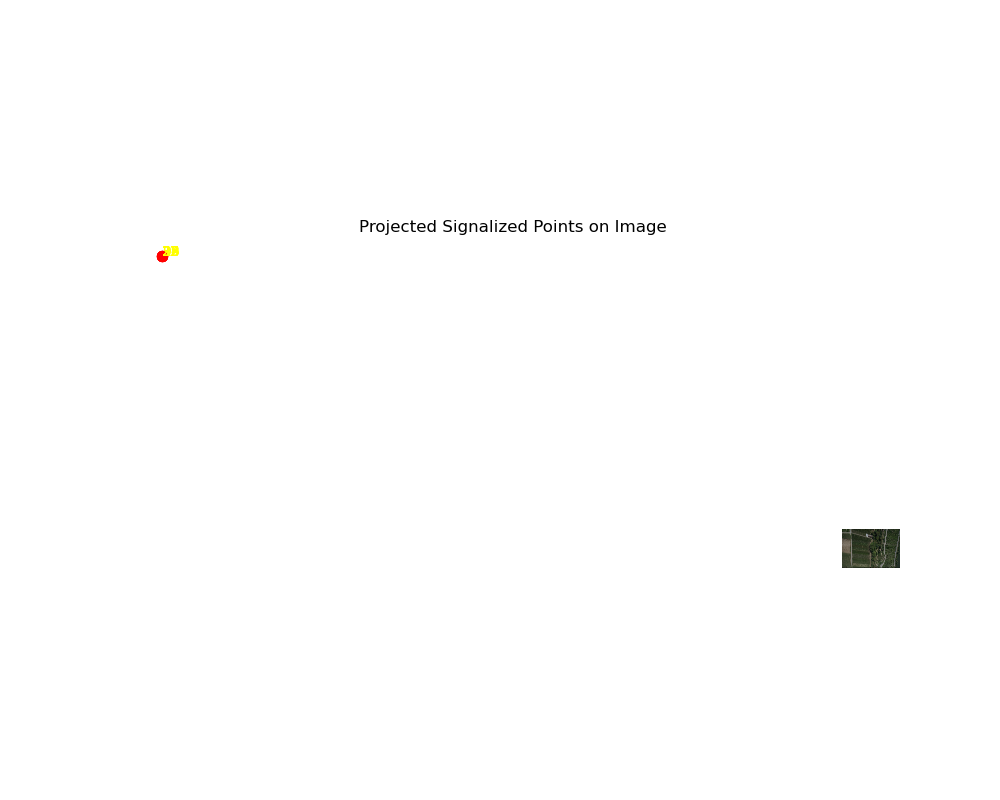

In [21]:
# Load and display the image
image = cv.imread(image_file)
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# YOUR CODE HERE
# Plot projected points on the image
plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.scatter(pixel_coords[:, 0], pixel_coords[:, 1],
            c='red', s=50, marker='o')

# Annotate point IDs
for i, point_id in enumerate(point_ids):
    plt.text(pixel_coords[i, 0] + 5,
             pixel_coords[i, 1] + 5,
             str(point_id),
             color='yellow',
             fontsize=10)

plt.title("Projected Signalized Points on Image")
plt.axis("off")
plt.show()


In [ ]:
## Do not change cell - required for auto-grading ## 

### Task 6: Direct Linear Transformation (DLT) (5 points)

Implement the Direct Linear Transformation (DLT) algorithm to compute the projection matrix directly from 3D-2D point correspondences.

#### Expected Output
- `P_dlt`: 3×4 projection matrix computed via DLT


In [22]:
def dlt_projection_matrix(object_points, image_points):
    """
    Compute projection matrix using Direct Linear Transformation (DLT)
    Args:
        object_points: Nx3 array of 3D object points
        image_points: Nx2 array of 2D image points
    Returns:
        3x4 projection matrix
    """
    P_dlt = None

    # YOUR CODE HERE
    # Convert to numpy arrays
    object_points = np.asarray(object_points)
    image_points = np.asarray(image_points)
    
    n = object_points.shape[0]
    
    # Build design matrix A (2N x 12)
    A = []
    
    for i in range(n):
        X, Y, Z = object_points[i]
        u, v = image_points[i]
    
        A.append([X, Y, Z, 1, 0, 0, 0, 0, -u*X, -u*Y, -u*Z, -u])
        A.append([0, 0, 0, 0, X, Y, Z, 1, -v*X, -v*Y, -v*Z, -v])
    
    A = np.array(A)
    
    # Solve using SVD
    _, _, Vt = np.linalg.svd(A)
    
    # Solution is the last row of V^T
    P_dlt = Vt[-1].reshape(3, 4)


    return P_dlt

# Apply DLT to compute projection matrix from 3D-2D correspondences
P_dlt = dlt_projection_matrix(object_points, pixel_coords)

print("DLT Projection Matrix P_DLT:")
print(P_dlt)

DLT Projection Matrix P_DLT:
[[-1.57304912e-07 -9.30257934e-08 -9.46996048e-08  7.22519812e-02]
 [-1.05744459e-07  1.55724704e-07 -4.94657954e-08 -9.97386410e-01]
 [-5.32979186e-12  2.30778917e-12 -4.57988452e-11  3.95313571e-07]]


In [ ]:
## Do not change cell - required for auto-grading ## 


Question 5: What is the minimum number of points required? why?


The minimum number of points required for DLT is 6 non-coplanar 3D–2D point correspondences.

Each 3D–2D correspondence provides two independent linear equations.
The projection matrix has 12 elements, but it is defined up to a scale factor, so there are 11 independent unknowns.
With 6 points we obtain 12 equations, which is the minimum required to solve the system.

Using more than 6 points makes the system over-determined and improves robustness against noise.

Question 6: Why do we use SVD to solve the DLT problem? What does the smallest singular value represent?


SVD is used because the DLT formulation leads to a homogeneous linear system that usually has no exact solution due to noise in the data.

SVD provides a least-squares solution by finding the vector that minimizes the algebraic error under a unit-norm constraint.

The smallest singular value corresponds to the direction in which the system has the least error.
The associated singular vector represents the best approximation of the projection matrix that satisfies the DLT equations.

### Task 7: Compare DLT-computed projection matrix vs. Original Projection (3 points)

Compare the accuracy of DLT-computed projection matrix with the original camera parameters by analyzing pixel coordinate differences.

#### Expected Results
- **Small differences** (< 0.1 pixel) indicate good DLT implementation


In [23]:
# Recompute pixel coordinates using DLT projection matrix
pixel_coords_dlt = None

# YOUR CODE HERE
# Recompute pixel coordinates using DLT projection matrix

# Convert object points to homogeneous coordinates (N x 4)
N = object_points.shape[0]
object_points_h = np.hstack([object_points, np.ones((N, 1))])

# Project points using DLT projection matrix
proj = (P_dlt @ object_points_h.T).T   # shape: N x 3

# Convert from homogeneous to pixel coordinates
pixel_coords_dlt = np.zeros((N, 2))
pixel_coords_dlt[:, 0] = proj[:, 0] / proj[:, 2]
pixel_coords_dlt[:, 1] = proj[:, 1] / proj[:, 2]


print("Pixel coordinates comparison:")
print("=" * 80)
print("Point ID | Original X | Original Y | DLT X     | DLT Y     | Diff X    | Diff Y")
print("-" * 80)
for i, (point_id, pixel_orig, pixel_dlt) in enumerate(zip(point_ids, pixel_coords, pixel_coords_dlt)):
    dx = pixel_orig[0] - pixel_dlt[0]
    dy = pixel_orig[1] - pixel_dlt[1]
    print(f"{point_id:8d} | {pixel_orig[0]:10.2f} | {pixel_orig[1]:10.2f} | {pixel_dlt[0]:9.2f} | {pixel_dlt[1]:9.2f} | {dx:9.3f} | {dy:9.3f}")

Pixel coordinates comparison:
Point ID | Original X | Original Y | DLT X     | DLT Y     | Diff X    | Diff Y
--------------------------------------------------------------------------------
      15 |  -50453.99 |  -20285.26 | -50453.99 | -20285.26 |     0.000 |     0.000
      24 |  -50468.64 |  -20290.20 | -50468.64 | -20290.20 |     0.000 |    -0.000
      25 |  -50472.43 |  -20293.84 | -50472.43 | -20293.84 |     0.000 |     0.000
      32 |  -50438.13 |  -20278.51 | -50438.13 | -20278.51 |    -0.000 |     0.000
      37 |  -50442.12 |  -20283.59 | -50442.12 | -20283.59 |     0.000 |    -0.000
      98 |  -50470.80 |  -20293.38 | -50470.80 | -20293.38 |     0.000 |    -0.000
      99 |  -50470.26 |  -20293.15 | -50470.26 | -20293.15 |     0.000 |    -0.000


In [ ]:
## Do not change cell - required for auto-grading ## 

Question 7: What factors influence the accuracy of parameter reconstruction from DLT? How can you assess the quality of the reconstruction?


The accuracy of parameter reconstruction from DLT is influenced by several factors.
An important factor is the quality and precision of the 3D–2D point correspondences; errors in measured image points or object coordinates directly affect the estimated projection matrix. The number of points also matters: using more well-distributed points generally improves stability and robustness. In addition, the geometric configuration of the points is critical; points should not be nearly coplanar and should cover the image area well. Numerical stability, including proper data normalization, also plays a key role in achieving accurate results.

The quality of the reconstruction can be assessed by analyzing reprojection errors, i.e. how well the reconstructed parameters project 3D points back to their observed image locations. Small pixel differences indicate a good reconstruction. Further validation can be done by comparing the DLT-derived projection matrix with known camera parameters or by testing the reconstruction on independent check points.

### Task 8: Reconstruct Camera Parameters from DLT Matrix (5 points)

Decompose the DLT-computed projection matrix to extract camera intrinsic and extrinsic parameters for comparison with original values.

### Expected Output
- `K_dlt`: 3×3 intrinsic matrix from DLT
- `R_dlt`: 3×3 rotation matrix from DLT
- `t_dlt`: 3x1 translation vector from DLT
- Comparison with original parameters


In [26]:
def decompose_projection_matrix(P):
    """
    Decompose projection matrix P into intrinsic K and extrinsic [R|t] matrices
    using RQ decomposition
    Returns:
        K: 3x3 intrinsic matrix
        R: 3x3 rotation matrix
        t: 3x1 translation vector (camera center in world coordinates)
    """
    K_dlt = None
    R_dlt = None
    t_dlt = None
    # YOUR CODE HERE
    import numpy as np

    # Split projection matrix
    M = P[:, :3]
    p4 = P[:, 3]
    
    # RQ decomposition via QR on reversed matrix
    def rq_decomposition(A):
        A_rev = np.flipud(np.fliplr(A))
        Q, R = np.linalg.qr(A_rev.T)
        R = np.flipud(np.fliplr(R.T))
        Q = np.flipud(np.fliplr(Q.T))
        return R, Q
    
    K_dlt, R_dlt = rq_decomposition(M)
    
    # Normalize K so that K[2,2] = 1
    K_dlt = K_dlt / K_dlt[2, 2]
    
    # Ensure positive diagonal of K
    T = np.diag(np.sign(np.diag(K_dlt)))
    K_dlt = K_dlt @ T
    R_dlt = T @ R_dlt
    
    # Camera center in world coordinates
    C = -np.linalg.inv(M) @ p4
    t_dlt = C.reshape(3,)



    return K_dlt, R_dlt, t_dlt

# Decompose DLT projection matrix
K_dlt, R_dlt, t_dlt = decompose_projection_matrix(P_dlt)

print("Comparison of camera matrix:")
diff_K = K_ori - K_dlt
print(diff_K)

print("\nComparison of rotation matrix:")
diff_R = R_ori - R_dlt
print(diff_R)

print("\nComparison of translation vector:")
diff_t = t_ori - t_dlt
print(f"Difference: {diff_t}")

Comparison of camera matrix:
[[-7735.43228806    70.1780959   -184.15370978]
 [   -0.            -8.0631565    -72.5360939 ]
 [    0.             0.             0.        ]]

Comparison of rotation matrix:
[[ 0.0078651  -0.01238693 -0.00428203]
 [ 1.08718286 -1.66542081 -0.21019204]
 [ 0.22851227 -0.10129211  1.98431716]]

Comparison of translation vector:
Difference: [3204091.77332473  671944.75988893 -560932.93932821]


In [ ]:
## Do not change cell - required for auto-grading ## 

#### Question 8: What factors might contribute to the small but measurable differences in the comparison?


Small but measurable differences in the comparison can arise from several factors.
First, the DLT method is sensitive to numerical precision, and small rounding errors during matrix construction and SVD computation can lead to slight differences.
Second, the projection matrix obtained from DLT is defined only up to an arbitrary scale, which can affect parameter comparisons even when pixel reprojection is accurate.
Third, the decomposition of the projection matrix into intrinsic and extrinsic parameters is not unique, and different normalization or sign conventions can introduce small discrepancies.
Finally, the limited number and spatial distribution of point correspondences can also influence numerical stability and lead to minor differences.